### Step:1 - import the required libraries

In [1]:
import pandas as pd                                     
import plotly.express as px                             
import matplotlib.pyplot as plt                         
import seaborn as sns                                   
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.metrics import confusion_matrix
import joblib


### Step:2 - import nykaa, purplle & tira datasets

### Step:2.1 - Import nykaa compaign data with nulls file 

In [2]:
nykaa_campaign_data = pd.read_csv(r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\data\nykaa_campaign_data_with_nulls.csv")
nykaa_campaign_dataframe = pd.DataFrame(nykaa_campaign_data)

# to find the shape of the records and features i.e. count of no of rows and columns
print("Data Shape:",nykaa_campaign_dataframe.shape)  

# to show info of each columns
print("\nData Info:")
nykaa_campaign_dataframe.info()

# to find the missing values
print("\nMissing values:")
print(nykaa_campaign_dataframe.isnull().sum())

# to show first 5 rows
print("\nFirst five records:")
print(nykaa_campaign_dataframe.head())

# to insert a new column in dataframe is df.insert(loc, column, value)
#  loc => index value where the columns must be inserted
#  column => label for new column (column_name)
#  value => data to be represented in this column
print("\nInsert Company_Name column inside the dataframe, value is Nykaa")
nykaa_campaign_dataframe.insert(1,'Campaign','Nykaa')

print("\nData Shape:",nykaa_campaign_dataframe.shape)

print("\nFirst five records:")
print(nykaa_campaign_dataframe.head())

print("\nDuplicate values:")
print(nykaa_campaign_dataframe.duplicated().sum())


Data Shape: (55555, 16)

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       55555 non-null  str    
 1   Campaign_Type     52696 non-null  str    
 2   Target_Audience   52794 non-null  str    
 3   Duration          52665 non-null  float64
 4   Channel_Used      52750 non-null  str    
 5   Impressions       52775 non-null  float64
 6   Clicks            52773 non-null  float64
 7   Leads             52776 non-null  float64
 8   Conversions       52889 non-null  float64
 9   Revenue           52743 non-null  float64
 10  Acquisition_Cost  52742 non-null  float64
 11  ROI               52730 non-null  float64
 12  Language          52787 non-null  str    
 13  Engagement_Score  52806 non-null  float64
 14  Customer_Segment  52767 non-null  str    
 15  Date              52797 non-null  str    
dtypes: float64(9), 

### Step:2.2 - Import purplle compaign data with nulls file 

In [3]:
purplle_campaign_data = pd.read_csv(r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\data\purplle_campaign_data_with_nulls.csv")
purplle_campaign_dataframe = pd.DataFrame(purplle_campaign_data)

print("Data Shape:",purplle_campaign_dataframe.shape)  

print("\nData Info:")
purplle_campaign_dataframe.info()

print("\nMissing values:")
print(purplle_campaign_dataframe.isnull().sum())

print("\nFirst five records:")
print(purplle_campaign_dataframe.head())

print("\nInsert Company_Name column inside the dataframe, value is Purplle")
purplle_campaign_dataframe.insert(1,'Campaign','Purplle')

print("\nData Shape:",purplle_campaign_dataframe.shape)

print("\nFirst five records:")
print(purplle_campaign_dataframe.head())

print("\nDuplicate values:")
print(purplle_campaign_dataframe.duplicated().sum())


Data Shape: (55555, 16)

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       52871 non-null  str    
 1   Campaign_Type     52765 non-null  str    
 2   Target_Audience   52808 non-null  str    
 3   Duration          52787 non-null  float64
 4   Channel_Used      52811 non-null  str    
 5   Impressions       52834 non-null  float64
 6   Clicks            52843 non-null  float64
 7   Leads             52901 non-null  float64
 8   Conversions       52881 non-null  float64
 9   Revenue           52792 non-null  float64
 10  Acquisition_Cost  52857 non-null  float64
 11  ROI               52824 non-null  float64
 12  Language          52810 non-null  str    
 13  Engagement_Score  52953 non-null  float64
 14  Customer_Segment  52879 non-null  str    
 15  Date              52904 non-null  str    
dtypes: float64(9), 

### Step:2.3 - Import tira compaign data with nulls file 

In [4]:
tira_campaign_data = pd.read_csv(r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\data\tira_campaign_data_with_nulls.csv")
tira_campaign_dataframe = pd.DataFrame(tira_campaign_data)

print("Data Shape:",tira_campaign_dataframe.shape)  

print("\nData Info:")
tira_campaign_dataframe.info()

print("\nMissing values:")
print(tira_campaign_dataframe.isnull().sum())

print("\nFirst five records:")
print(tira_campaign_dataframe.head())

print("\nInsert Company_Name column inside the dataframe, value is Tira")
tira_campaign_dataframe.insert(1,'Campaign','Tira')

print("\nData Shape:",tira_campaign_dataframe.shape)

print("\nFirst five records:")
print(tira_campaign_dataframe.head())

print("\nDuplicate values:")
print(tira_campaign_dataframe.duplicated().sum())


Data Shape: (55555, 16)

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       52822 non-null  str    
 1   Campaign_Type     52846 non-null  str    
 2   Target_Audience   52891 non-null  str    
 3   Duration          52890 non-null  float64
 4   Channel_Used      52822 non-null  str    
 5   Impressions       52832 non-null  float64
 6   Clicks            52825 non-null  float64
 7   Leads             52898 non-null  float64
 8   Conversions       52895 non-null  float64
 9   Revenue           52826 non-null  float64
 10  Acquisition_Cost  52905 non-null  float64
 11  ROI               52813 non-null  float64
 12  Language          52769 non-null  str    
 13  Engagement_Score  52825 non-null  float64
 14  Customer_Segment  52844 non-null  str    
 15  Date              52865 non-null  str    
dtypes: float64(9), 

### Step:3 - Now concatinating (merging) nykaa, purplle & tira dataframes into single dataframes

In [5]:
# to combine the three dataframes, combined_df = pd.concat([df1,df2,df3], axis=0, ignore_index=True)

# axis = 0            => datas added vertically, records by records
# axis = 1            => datas added horizontally, features by features like adding new columns
# ignore_index = True => index from df1, df2, df3 will be ignored and new index will be added.

nykaa_purplle_tira_campaign_combined_dataframe = pd.concat([nykaa_campaign_dataframe,purplle_campaign_dataframe,tira_campaign_dataframe],axis=0, ignore_index=True)
print("Data shape:", nykaa_purplle_tira_campaign_combined_dataframe.shape)

print("\nMissing values:")
print(nykaa_purplle_tira_campaign_combined_dataframe.isnull().sum())

print("\nNumber of Duplicate Rows:", nykaa_purplle_tira_campaign_combined_dataframe.duplicated().sum())


Data shape: (166665, 17)

Missing values:
Campaign_ID         5417
Campaign               0
Campaign_Type       8358
Target_Audience     8172
Duration            8323
Channel_Used        8282
Impressions         8224
Clicks              8224
Leads               8090
Conversions         8000
Revenue             8304
Acquisition_Cost    8161
ROI                 8298
Language            8299
Engagement_Score    8081
Customer_Segment    8175
Date                8099
dtype: int64

Number of Duplicate Rows: 0


### Step:4 - Data Preprocessing:

In [6]:
# Data PreProcessing:

# To remove the records which has null value in the column name is "Campaign_Type", "Channel_Used","Target_Audience","Date","Language".
# df.dropna(subset = ['column1', 'column2', 'column3'], inplace=True) 
# inplace = True => reflects in original dataframe
#            (or)
# df = df.dropna(subset = ['column1', 'column2','column3])

# Drop the records which has null values:
print("Drop the records which has null values:")
nykaa_purplle_tira_campaign_combined_dataframe = (
    nykaa_purplle_tira_campaign_combined_dataframe.dropna(subset = ['Campaign_Type','Channel_Used','Target_Audience',
                        'Date','Language','Customer_Segment','Duration']))

# Fill zero in the missing value in Revenue feature:
print("\nFill zero in the missing value in Revenue feature:")
nykaa_purplle_tira_campaign_combined_dataframe['Revenue'] = nykaa_purplle_tira_campaign_combined_dataframe['Revenue'].fillna(0)

print("\nMissing values:")
print(nykaa_purplle_tira_campaign_combined_dataframe.isnull().sum())


# Fill missing values in 'Impressions','Clicks','Leads','Conversions','Acquisition_Cost','Engagement_Score' 
#                                                              by finding mean value under Nykaa Campaign:
print("\nFill missing values in 'Impressions','Clicks','Leads','Conversions','Acquisition_Cost','Engagement_Score' by finding mean value:" )
print("Campaign = Nykaa" )
nykaa_condition = (nykaa_purplle_tira_campaign_combined_dataframe['Campaign'] == 'Nykaa')
nykaa_mean = nykaa_purplle_tira_campaign_combined_dataframe.loc[nykaa_condition, 
                            ['Impressions','Clicks','Leads','Conversions','Acquisition_Cost','Engagement_Score']].mean().round(2)

nykaa_purplle_tira_campaign_combined_dataframe.loc[nykaa_condition,
                            ['Impressions','Clicks','Leads','Conversions','Acquisition_Cost','Engagement_Score']] = (
                             nykaa_purplle_tira_campaign_combined_dataframe.loc[nykaa_condition,
                            ['Impressions','Clicks','Leads','Conversions','Acquisition_Cost','Engagement_Score']].fillna(nykaa_mean))
print("Calculated_mean: ")
print(f"{nykaa_mean}")


# Fill missing values in 'Impressions','Clicks','Leads','Conversions','Acquisition_Cost','Engagement_Score' 
#                                                              by finding mean value under Purplle Campaign:
print("\nFill missing values in 'Impressions','Clicks','Leads','Conversions','Acquisition_Cost','Engagement_Score' by finding mean value:" )
print("Campaign = Purplle" )
purplle_condition = (nykaa_purplle_tira_campaign_combined_dataframe['Campaign'] == 'Purplle')
purplle_mean = nykaa_purplle_tira_campaign_combined_dataframe.loc[purplle_condition, 
                        ['Impressions','Clicks','Leads','Conversions','Acquisition_Cost','Engagement_Score']].mean().round(2)

nykaa_purplle_tira_campaign_combined_dataframe.loc[purplle_condition,
                        ['Impressions','Clicks','Leads','Conversions','Acquisition_Cost','Engagement_Score']] = (
    nykaa_purplle_tira_campaign_combined_dataframe.loc[purplle_condition,
                            ['Impressions','Clicks','Leads','Conversions','Acquisition_Cost','Engagement_Score']].fillna(purplle_mean))
print("Calculated_mean: " )
print(f"{purplle_mean}")


# Fill missing values in 'Impressions','Clicks','Leads','Conversions','Acquisition_Cost','Engagement_Score' 
#                                                              by finding mean value under Purplle Campaign:
print("\nFill missing values in 'Impressions','Clicks','Leads','Conversions','Acquisition_Cost','Engagement_Score' by finding mean value:" )
print("Campaign = Tira" )
tira_condition = (nykaa_purplle_tira_campaign_combined_dataframe['Campaign'] == 'Tira')
tira_mean = nykaa_purplle_tira_campaign_combined_dataframe.loc[tira_condition, 
                            ['Impressions','Clicks','Leads','Conversions','Acquisition_Cost','Engagement_Score']].mean().round(2)

nykaa_purplle_tira_campaign_combined_dataframe.loc[tira_condition,
                            ['Impressions','Clicks','Leads','Conversions','Acquisition_Cost','Engagement_Score']] = (
    nykaa_purplle_tira_campaign_combined_dataframe.loc[tira_condition, 
                            ['Impressions','Clicks','Leads','Conversions','Acquisition_Cost','Engagement_Score']].fillna(tira_mean))
print("Calculated_mean: " )
print(f"{tira_mean}")

print("\nMissing values:")
print(nykaa_purplle_tira_campaign_combined_dataframe.isnull().sum())


# Add a new Feature 'profit' and find 'Profit' using 'Revenue' and 'Acquistion_Cost':
# df = df.assign(New_Column_Name = lamda X: X['Column_1'] + X['Column_2'])
print("\n1. Add a new Feature 'profit' and find 'Profit' using 'Revenue' and 'Acquistion_Cost':")
nykaa_purplle_tira_campaign_combined_dataframe = (
    nykaa_purplle_tira_campaign_combined_dataframe.assign(Profit=lambda X: X['Revenue'] - X['Acquisition_Cost'])
                                        ) 


# Add a new Feature 'New_calc_ROI' and find 'New_calc_ROI' using 'Profit' and 'Acquistion_Cost':
print("\n2. Add a new Feature 'New_calc_ROI' and find 'New_calc_ROI' using 'Profit' and 'Acquistion_Cost':")
nykaa_purplle_tira_campaign_combined_dataframe = (
                nykaa_purplle_tira_campaign_combined_dataframe.assign(New_Calc_ROI=lambda X: X['Profit'] / X['Acquisition_Cost'])
                                        )


# Round off the decimal numbers upto two decimal point:
#df.round({"Column_1": 1, "Column_2": 2})
print("\n3. Round off the decimal numbers upto two decimal point in 'Profit' and 'New_Calc_ROI' Features: ")
nykaa_purplle_tira_campaign_combined_dataframe = (
     nykaa_purplle_tira_campaign_combined_dataframe.round({"Profit": 2, "New_Calc_ROI": 2})
                                        )


# Add new column 'New calculated ROI in percentage' and perform operation 'New_Calc_ROI' * 100 to assign a value:
print("\n4. Add a new Feature 'New_calc_ROI_Per' and find 'New_calc_ROI_Per' using percentage concept:")
nykaa_purplle_tira_campaign_combined_dataframe = (
                nykaa_purplle_tira_campaign_combined_dataframe.assign(New_Calc_ROI_Per=lambda X: X['New_Calc_ROI'] * 100)
                                        )


# Add new column 'Profit_Loss' and find Profit or Loss using 'New_Calc_ROI' feature :
print("\n4. Add a new Feature 'Profit_Loss' and find Profit or Loss using 'Profit' feature:")
nykaa_purplle_tira_campaign_combined_dataframe['Profit_Loss'] = (
    nykaa_purplle_tira_campaign_combined_dataframe['New_Calc_ROI'].apply(lambda x: 1 if x > 0 else 0))
print(nykaa_purplle_tira_campaign_combined_dataframe['Profit_Loss'].value_counts())


nykaa_purplle_tira_campaign_combined_dataframe['Profit_or_Loss'] = (
    nykaa_purplle_tira_campaign_combined_dataframe['New_Calc_ROI'].apply(lambda x: "Profit" if x > 0 else "Loss"))
print(nykaa_purplle_tira_campaign_combined_dataframe['Profit_or_Loss'].value_counts())


# Split Date column into Day, Month and Year columns:
# df[["Day","Month","Year"]] = df["Date"].str.split("-", expand=True).astype(int)
print("\n5. Split Date column into Day, Month and Year columns: ")
nykaa_purplle_tira_campaign_combined_dataframe[["Day", "Month", "Year"]] = (
                                  nykaa_purplle_tira_campaign_combined_dataframe["Date"].str.split("-", expand=True).astype(int)
                                                                            )


print("\nDataFrame after splitting Date into Day, Month and Year:")
print(nykaa_purplle_tira_campaign_combined_dataframe.head())

print("\nMissing values:")
print(nykaa_purplle_tira_campaign_combined_dataframe.isnull().sum())

print("\nData shape:", nykaa_purplle_tira_campaign_combined_dataframe.shape)
print("\nInformation: ")
print(nykaa_purplle_tira_campaign_combined_dataframe.info())

print("\nAfter Reseting the index column:")
nykaa_purplle_tira_campaign_combined_dataframe = nykaa_purplle_tira_campaign_combined_dataframe.reset_index(drop=True)
print(nykaa_purplle_tira_campaign_combined_dataframe)

print(nykaa_purplle_tira_campaign_combined_dataframe.isnull().sum())


Drop the records which has null values:

Fill zero in the missing value in Revenue feature:

Missing values:
Campaign_ID         3811
Campaign               0
Campaign_Type          0
Target_Audience        0
Duration               0
Channel_Used           0
Impressions         5711
Clicks              5775
Leads               5741
Conversions         5696
Revenue                0
Acquisition_Cost    5751
ROI                 5847
Language               0
Engagement_Score    5630
Customer_Segment       0
Date                   0
dtype: int64

Fill missing values in 'Impressions','Clicks','Leads','Conversions','Acquisition_Cost','Engagement_Score' by finding mean value:
Campaign = Nykaa
Calculated_mean: 
Impressions         54977.64
Clicks               4663.97
Leads                1870.62
Conversions          1029.90
Acquisition_Cost      377.95
Engagement_Score       13.77
dtype: float64

Fill missing values in 'Impressions','Clicks','Leads','Conversions','Acquisition_Cost','Engagement

### EDA:

In [7]:
# EDA:
nykaa_purplle_tira_eda_df = nykaa_purplle_tira_campaign_combined_dataframe.copy()
print(nykaa_purplle_tira_eda_df.isnull().sum())

nykaa_purplle_tira_eda_df = nykaa_purplle_tira_eda_df.drop(['Campaign_ID','ROI','Date'], axis = 1)
print(nykaa_purplle_tira_eda_df.isnull().sum())
nykaa_purplle_tira_eda_df.to_csv(r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\cleaned_data\nykaa_purplle_tira_combined_files\nykaa_purplle_tira_eda_df.csv")


Campaign_ID         3811
Campaign               0
Campaign_Type          0
Target_Audience        0
Duration               0
Channel_Used           0
Impressions            0
Clicks                 0
Leads                  0
Conversions            0
Revenue                0
Acquisition_Cost       0
ROI                 5847
Language               0
Engagement_Score       0
Customer_Segment       0
Date                   0
Profit                 0
New_Calc_ROI           0
New_Calc_ROI_Per       0
Profit_Loss            0
Profit_or_Loss         0
Day                    0
Month                  0
Year                   0
dtype: int64
Campaign            0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
Language            0
Engagement_Score    0
Customer_Segment    0
Profit              0
New_Calc_ROI        0
New_Calc_R

In [8]:
# Revenue distribution by Brands:
revenue_brand_analysis_df = (
    nykaa_purplle_tira_eda_df.groupby('Campaign', as_index=False)['Revenue'].sum()
                            )

revenue_brand_analysis_fig = px.bar(
                                    revenue_brand_analysis_df,
                                    x='Campaign',
                                    y='Revenue',
                                    color='Campaign',
                                    title='Revenue Distribution by Brands',
                                    text='Revenue'
                                   )

revenue_brand_analysis_fig.update_traces(
                                        texttemplate='%{text:,.0f}',
                                        textposition='outside'
                                        )

revenue_brand_analysis_fig.update_yaxes(tickformat=',')

revenue_brand_analysis_fig.update_layout(
                                        title_x=0.4,
                                        xaxis_title='Campaign',
                                        yaxis_title='Revenue',
                                        showlegend=False,
                                        width=700,
                                        height=500
                                        )

revenue_brand_analysis_fig.show()

In [9]:
joblib.dump(revenue_brand_analysis_fig, r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\models\revenue_brand_analysis_chart.pkl")
print("Revenue and brand analysis chart saved successfully!")

Revenue and brand analysis chart saved successfully!


In [10]:
# ROI by Campaign Type and Campaign:
roi_campaign_type_analysis = (
                        nykaa_purplle_tira_eda_df.groupby(["Campaign_Type", "Campaign"])["New_Calc_ROI"].mean().reset_index()
                                )

roi_campaign_type_analysis_fig = px.bar(roi_campaign_type_analysis, x="Campaign_Type", y="New_Calc_ROI", color="Campaign", barmode="group",
                                 title="Average ROI by Campaign Type & Brand",
                                 labels={
                                    "Campaign_Type": "Campaign Type",
                                    "New_Calc_ROI": "ROI",
                                    "Campaign": "Brand"
                                        }
                                 )
roi_campaign_type_analysis_fig.update_layout(width=1100, height=600, legend_title="Brand", title_x = 0.3)
roi_campaign_type_analysis_fig.show()

joblib.dump(roi_campaign_type_analysis_fig, r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\models\roi_campaign_type_analysis_chart.pkl")
print("ROI, Campaign type and Campaign analysis chart saved Successfully!")



ROI, Campaign type and Campaign analysis chart saved Successfully!


In [11]:
# profit vs Loss count by Brand:
profit_loss_campaign_analysis = (
                 nykaa_purplle_tira_eda_df.groupby(["Campaign", "Profit_Loss"]).size().reset_index(name="Count")
                                )
profit_loss_campaign_analysis["Label"] = (
                    profit_loss_campaign_analysis["Profit_Loss"].map({
                                        1: "Profit",
                                        0: "Loss"
                                        }))

profit_loss_campaign_analysis_fig = px.bar(profit_loss_campaign_analysis, x="Campaign", y="Count", color="Label",
                                    barmode="group",
                                    title="Profit vs Loss Count by Brand",
                                    labels={
                                            "Campaign": "Brand",
                                            "Count": "Count",
                                            "Label": "Status"
                                        }
                                        )
profit_loss_campaign_analysis_fig.update_layout(width=900,height=500,legend_title="Status", title_x = 0.3)
profit_loss_campaign_analysis_fig.show()

joblib.dump(profit_loss_campaign_analysis_fig, r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\models\profit_loss_campaign_analysis_chart.pkl")
print("profit and loss campaign chart is saved successfully!")



profit and loss campaign chart is saved successfully!


### Step:4 - one-Hot Encoding:

#### Now split the Channel_Used columns into Channel_Used_Email, Channel_Used_Facebook, Channel_Used_Google, Channel_Used_Instagram,Channel_Used_WhatsApp, Channel_Used_YouTube



In [12]:
# One Hot encoding:

# df.['column'].str.split(', ').str.join('|').str.get_dummies().add_prefix('word_')
# .str.split(', ')     =>  split the strings
# .str.join('|')       =>  join the strings
# .str.get_dummies()   =>  create individual dummy column and give values in numerical as '1' and '0'.
# .add_prefix('Channel_Used')  =>  function is used to add prefix in each column name. 


print("One Hot Encoding process:")
nykaa_purplle_tira_one_hot_encoded = (nykaa_purplle_tira_campaign_combined_dataframe['Channel_Used'].str.split(', ').str.join('|')
                                      .str.get_dummies().add_prefix('Channel_Used_'))

all_channels_used = nykaa_purplle_tira_one_hot_encoded.copy()

print(nykaa_purplle_tira_one_hot_encoded.head())


print("\nBefore Concatinating Data Shape of Orginal Dataframe columns:", nykaa_purplle_tira_campaign_combined_dataframe.shape)
print("\nBefore Concatinating Data Shape of enocoded columns:", nykaa_purplle_tira_one_hot_encoded.shape)


# concatinate the original dataframe and encoded columns horizontally:
print("\nConcatinate the encoded features in original dataframe: ")
nykaa_purplle_tira_dataframe_encoded = pd.concat([nykaa_purplle_tira_campaign_combined_dataframe, nykaa_purplle_tira_one_hot_encoded], axis=1)

print("\nAfter Concatinating, Data Shape:", nykaa_purplle_tira_dataframe_encoded.shape)
print("\nFirst five Records: ")
print(nykaa_purplle_tira_dataframe_encoded.head())

print("\nInformation: ")
print(nykaa_purplle_tira_dataframe_encoded.info())

print(all_channels_used)


One Hot Encoding process:
   Channel_Used_Email  Channel_Used_Facebook  Channel_Used_Google  \
0                   0                      0                    0   
1                   0                      0                    0   
2                   0                      0                    1   
3                   0                      1                    0   
4                   0                      0                    1   

   Channel_Used_Instagram  Channel_Used_WhatsApp  Channel_Used_YouTube  
0                       0                      1                     1  
1                       0                      0                     1  
2                       0                      1                     1  
3                       1                      0                     0  
4                       0                      1                     1  

Before Concatinating Data Shape of Orginal Dataframe columns: (116811, 25)

Before Concatinating Data Shape of enocoded 

### Step:5 - Label Encoding:

In [13]:
# label encoding:

print("\nLabel Encoding process: ")
print("\nLabel Encoding is done for 'Campaign', 'Campaign_Type', Target_Audience', 'Language', 'Customer_Segment' Features: ")


le = LabelEncoder()
# df['column_encoded'] = le.fit_transform(df['column'])
nykaa_purplle_tira_dataframe_encoded['Campaign_Encoded'] = (
                                   le.fit_transform(nykaa_purplle_tira_dataframe_encoded['Campaign']))

nykaa_purplle_tira_dataframe_encoded['Campaign_Type_Encoded'] = (
                                   le.fit_transform(nykaa_purplle_tira_dataframe_encoded['Campaign_Type']))

nykaa_purplle_tira_dataframe_encoded['Target_Audience_Encoded'] = (
                                   le.fit_transform(nykaa_purplle_tira_dataframe_encoded['Target_Audience']))

nykaa_purplle_tira_dataframe_encoded['Language_Encoded'] = (
                                   le.fit_transform(nykaa_purplle_tira_dataframe_encoded['Language']))

nykaa_purplle_tira_dataframe_encoded['Customer_Segment_Encoded'] = (
                                   le.fit_transform(nykaa_purplle_tira_dataframe_encoded['Customer_Segment']))


print("\nData Shape:", nykaa_purplle_tira_dataframe_encoded.shape)
print("\nFirst five Records: ")
print(nykaa_purplle_tira_dataframe_encoded.head())

print("\nInformation: ")
print(nykaa_purplle_tira_dataframe_encoded.info())

print("\nMissing values:")
print(nykaa_purplle_tira_dataframe_encoded.isnull().sum())

nykaa_purplle_tira_dataframe_encoded.to_csv(r"""C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\cleaned_data\nykaa_purplle_tira_combined_files\nykaa_purplle_tira_dataframe_encoded.csv""")



Label Encoding process: 

Label Encoding is done for 'Campaign', 'Campaign_Type', Target_Audience', 'Language', 'Customer_Segment' Features: 

Data Shape: (116811, 36)

First five Records: 
   Campaign_ID Campaign Campaign_Type        Target_Audience  Duration  \
0  NY-CMP-1000    Nykaa  Social Media       College Students      21.0   
1  NY-CMP-1001    Nykaa      Paid Ads  Tier 2 City Customers      18.0   
2  NY-CMP-1002    Nykaa    Influencer                  Youth      23.0   
3  NY-CMP-1004    Nykaa      Paid Ads       College Students      10.0   
4  NY-CMP-1006    Nykaa      Paid Ads       College Students      21.0   

                Channel_Used  Impressions   Clicks   Leads  Conversions  ...  \
0          WhatsApp, YouTube      57804.0  6156.00  3616.0       2355.0  ...   
1                    YouTube      91801.0  3321.00  1971.0       1357.0  ...   
2  WhatsApp, Google, YouTube      15536.0  2182.00   952.0        755.0  ...   
3        Facebook, Instagram      96871.0  3

### Step:6 - Drop the unwanted feautures for ML 

In [14]:
print("\nMake a copy of original dataframe and use it in ML ")
nykaa_purplle_tira_df = nykaa_purplle_tira_dataframe_encoded.copy()
print(nykaa_purplle_tira_df.head())

# Drop the unwanted columns => Campaign_ID, Campaign, Channel_Used, Campaign_Type, Language, Customer_Segment, 
#                              Target_Audience, ROI, Date:
print("\nDrop the unwanted columns:")
nykaa_purplle_tira_df = nykaa_purplle_tira_df.drop(['Campaign_ID','Campaign','Channel_Used','Campaign_Type','Language','Customer_Segment',
                                   'Target_Audience','ROI','Date','Profit','Profit_or_Loss','New_Calc_ROI_Per'], axis = 1)

print("\nFirst Five Records: ")
print(nykaa_purplle_tira_df.head())

print("\nData Shape:", nykaa_purplle_tira_df.shape)

print("\nMissing values: ")
print(nykaa_purplle_tira_df.isnull().sum())



Make a copy of original dataframe and use it in ML 
   Campaign_ID Campaign Campaign_Type        Target_Audience  Duration  \
0  NY-CMP-1000    Nykaa  Social Media       College Students      21.0   
1  NY-CMP-1001    Nykaa      Paid Ads  Tier 2 City Customers      18.0   
2  NY-CMP-1002    Nykaa    Influencer                  Youth      23.0   
3  NY-CMP-1004    Nykaa      Paid Ads       College Students      10.0   
4  NY-CMP-1006    Nykaa      Paid Ads       College Students      21.0   

                Channel_Used  Impressions   Clicks   Leads  Conversions  ...  \
0          WhatsApp, YouTube      57804.0  6156.00  3616.0       2355.0  ...   
1                    YouTube      91801.0  3321.00  1971.0       1357.0  ...   
2  WhatsApp, Google, YouTube      15536.0  2182.00   952.0        755.0  ...   
3        Facebook, Instagram      96871.0  3743.00  2060.0       1258.0  ...   
4  YouTube, Google, WhatsApp      82267.0  4663.97  1873.0       1386.0  ...   

   Channel_Used_Faceb

### Step:7 - Correlation Analysis:


Correlation Analysis:
                          Impressions    Clicks     Leads  Conversions  \
Impressions                  1.000000  0.659983  0.587829     0.539365   
Clicks                       0.659983  1.000000  0.846777     0.777307   
Leads                        0.587829  0.846777  1.000000     0.874157   
Conversions                  0.539365  0.777307  0.874157     1.000000   
Acquisition_Cost            -0.413877 -0.458664 -0.452081    -0.441114   
New_Calc_ROI                 0.319361  0.495773  0.592790     0.679011   
Revenue                      0.461396  0.664261  0.748316     0.814716   
Profit_Loss                  0.002028  0.000314 -0.000164     0.001457   
Engagement_Score             0.000012  0.594689  0.633297     0.611152   
Day                         -0.000219  0.000847  0.001374     0.004024   
Month                        0.003135  0.001195  0.000803     0.001125   
Year                        -0.003968 -0.004364 -0.003969    -0.005530   
Duration       

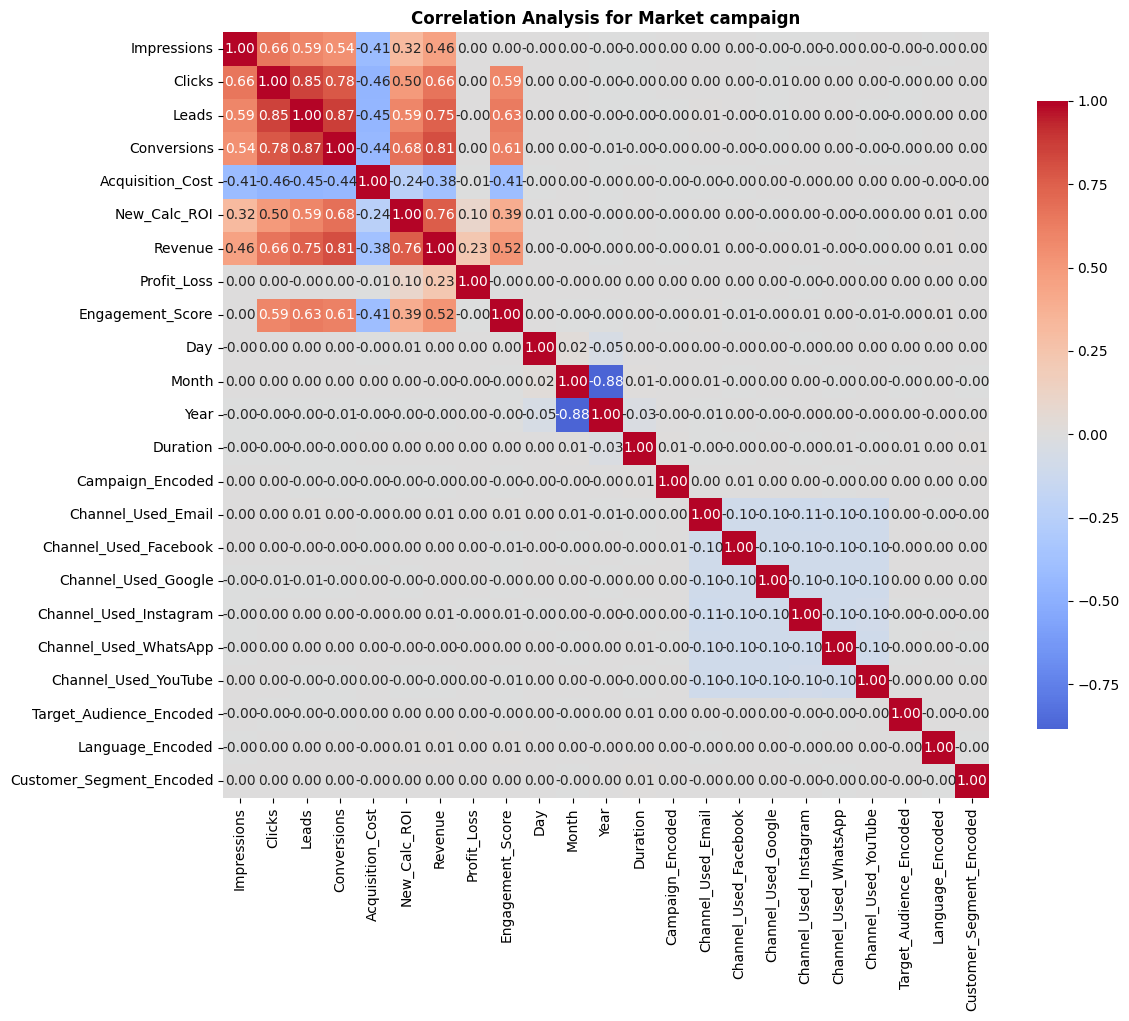

Correlation with Market Campaign: 
Revenue                     1.000000
Conversions                 0.814716
New_Calc_ROI                0.758087
Leads                       0.748316
Clicks                      0.664261
Engagement_Score            0.522004
Impressions                 0.461396
Profit_Loss                 0.227984
Language_Encoded            0.006649
Channel_Used_Email          0.005416
Channel_Used_Instagram      0.005319
Day                         0.003408
Customer_Segment_Encoded    0.003118
Duration                    0.000696
Channel_Used_Facebook       0.000068
Target_Audience_Encoded     0.000031
Channel_Used_Google        -0.000003
Channel_Used_WhatsApp      -0.000476
Month                      -0.000917
Campaign_Encoded           -0.001438
Channel_Used_YouTube       -0.002750
Year                       -0.002944
Acquisition_Cost           -0.377241
Name: Revenue, dtype: float64


In [15]:
# Correlation Analysis:
# Correlation tells us how strongly two variables are related
# Values range from -1 to +1:
# - +1: Perfect positive correlation (when one goes up, the other goes up)
# - 0: No correlation
# - -1: Perfect negative correlation (when one goes up, the other goes down)

correlation_columns = ['Impressions','Clicks','Leads','Conversions','Acquisition_Cost','New_Calc_ROI','Revenue',
                        'Profit_Loss','Engagement_Score','Day','Month','Year','Duration','Campaign_Encoded','Channel_Used_Email',
                        'Channel_Used_Facebook','Channel_Used_Google','Channel_Used_Instagram','Channel_Used_WhatsApp',
                        'Channel_Used_YouTube','Target_Audience_Encoded','Language_Encoded','Customer_Segment_Encoded']

regression_correlation_matrix = nykaa_purplle_tira_df[correlation_columns].corr()

print("\nCorrelation Analysis:")
print(regression_correlation_matrix)

# Heatmap:
plt.figure(figsize= (12,12))
sns.heatmap(regression_correlation_matrix, square= True, annot= True, 
                                center=0, cmap = 'coolwarm', fmt= '.2f', cbar_kws={"shrink": .6})
plt.title('Correlation Analysis for Market campaign' , fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.show()


print("Correlation with Market Campaign: ")
print(regression_correlation_matrix['Revenue'].sort_values(ascending=False))

nykaa_purplle_tira_df.to_csv(r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\cleaned_data\nykaa_purplle_tira_combined_files\nykaa_purplle_tira_df.csv")


In [16]:
# Heatmap: using Plotly:
regression_correlation_heatmap_fig = px.imshow(regression_correlation_matrix, 
                                                 title='Correlation Analysis for Market campaign for Regression Model',
                                                 color_continuous_scale="RDBu_r",
                                                 color_continuous_midpoint=0,
                                                 labels = dict(color="Correlation",fontsize = 10, fontweight = 'bold'),
                                                 text_auto='.2f',
                                                 aspect="equal"                              
                                                  )
regression_correlation_heatmap_fig.update_layout(title_x = 0.30,
                                                   width=1050,
                                                   height=1000,
                                                   xaxis=dict(tickangle=-90),
                                                   coloraxis_colorbar=dict(
                                                   len=0.9,                      
                                                   yanchor="middle",             
                                                   y=0.5     )
                                                      )
regression_correlation_heatmap_fig.show()

joblib.dump(regression_correlation_heatmap_fig, r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\models\regression_correlation_heatmap_chart.pkl" )
print("correlation heatmap analysis is saved sucessfuly!")

correlation heatmap analysis is saved sucessfuly!


### Step:8 - Feature Engineering

Features selected: 22
Target variable: Revenue
Feature names: ['Impressions', 'Clicks', 'Leads', 'Acquisition_Cost', 'New_Calc_ROI', 'Engagement_Score', 'Conversions', 'Campaign_Encoded', 'Campaign_Type_Encoded', 'Target_Audience_Encoded', 'Language_Encoded', 'Customer_Segment_Encoded', 'Channel_Used_Email', 'Channel_Used_Facebook', 'Channel_Used_Google', 'Channel_Used_Instagram', 'Channel_Used_WhatsApp', 'Channel_Used_YouTube', 'Duration', 'Day', 'Month', 'Year']

Check skewness: 
Matplot Graph:


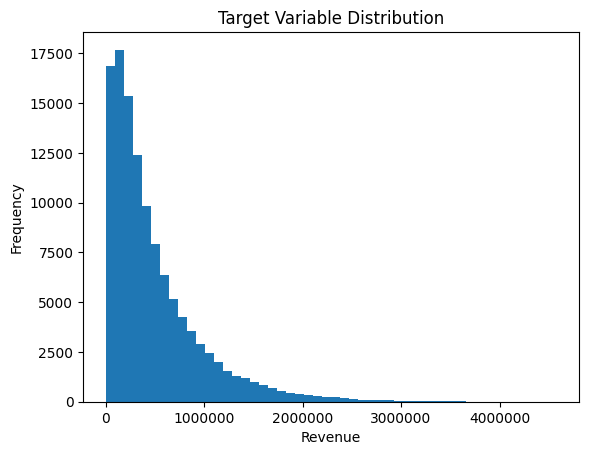

Skewness: 2.0391518597871734
count    1.168110e+05
mean     4.888818e+05
std      4.890763e+05
min      0.000000e+00
25%      1.550380e+05
50%      3.352560e+05
75%      6.603765e+05
max      4.579910e+06
Name: Revenue, dtype: float64


In [17]:
# Feature engineering
# Now we'll select the specific features we want to use for our prediction model

reg_features = ['Impressions','Clicks','Leads','Acquisition_Cost','New_Calc_ROI','Engagement_Score','Conversions','Campaign_Encoded',
            'Campaign_Type_Encoded','Target_Audience_Encoded','Language_Encoded','Customer_Segment_Encoded','Channel_Used_Email',
            'Channel_Used_Facebook','Channel_Used_Google','Channel_Used_Instagram','Channel_Used_WhatsApp','Channel_Used_YouTube',
            'Duration','Day','Month','Year']             

reg_target = 'Revenue'  

# Create our feature matrix (X) and target vector (y)
X = nykaa_purplle_tira_df[reg_features]  # All the input variables, X (capital): Represents our input features (independent variables)
y = nykaa_purplle_tira_df[reg_target]    # The output variable we want to predict, y (lowercase): Represents our target variable (dependent variable)
# - The goal is to find how X affects y

print(f"Features selected: {len(reg_features)}")
print(f"Target variable: {reg_target}")
print(f"Feature names: {reg_features}")

# Check skewness
print("\nCheck skewness: ")
print("Matplot Graph:")
plt.hist(y, bins=50)
plt.title("Target Variable Distribution")
plt.ticklabel_format(style='plain', axis='x')
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

print(f"Skewness: {y.skew()}")  # If > 1, it's heavily skewed
print(y.describe())


In [18]:
joblib.dump(reg_features, r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\models\regression_features.pkl")
print("Model trained and saved as model.pkl")


Model trained and saved as model.pkl


### Step:9 - Splitting the Data for Training and Testing 

Skewness Before log transform: 2.0365
Skewness After log transform:  -3.4592


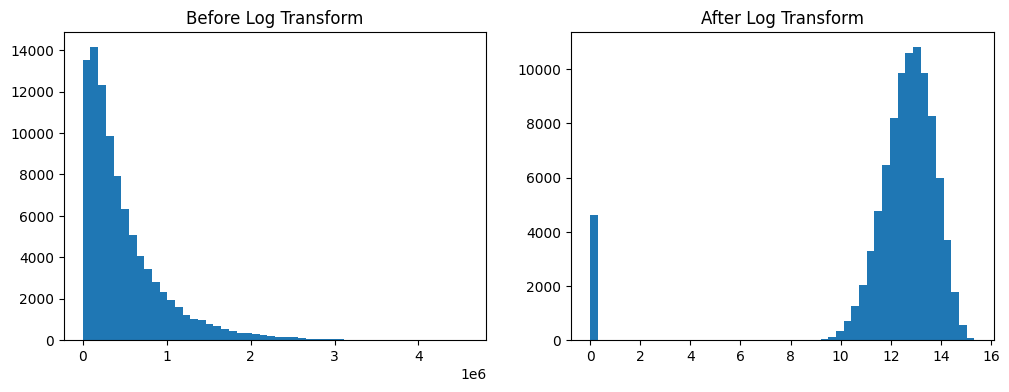

Training set shape: (93448, 22)
Testing set shape: (23363, 22)

Training set size in X (Total records): 93448
Testing set size in X (Total records) : 23363

Training set size in y (Total records): 93448
Testing set size in y (Total records) : 23363
Model trained and saved as model.pkl


In [19]:
# Split the data into training and testing sets
# This is one of the most important steps in machine learning!

# - Training set: Used to teach the model the patterns in the data
# - Testing set: Used to evaluate how well the model learned (unseen data)
# - This prevents the model from 'cheating' by memorizing the answers

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)
# test_size=0.2 means 20% of data for testing, 80% for training
# random_state=42 ensures we get the same split every time (for reproducibility)

# Log transform:
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)
 
print(f"Skewness Before log transform: {y_train.skew():.4f}")
print(f"Skewness After log transform:  {y_train_log.skew():.4f}")
 
# Visualise both
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].hist(y_train, bins=50)
axes[0].set_title("Before Log Transform")
 
axes[1].hist(y_train_log, bins=50)
axes[1].set_title("After Log Transform")
 
plt.show()


print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print(f"\nTraining set size in X (Total records): {X_train.shape[0]}")
print(f"Testing set size in X (Total records) : {X_test.shape[0]}")

print(f"\nTraining set size in y (Total records): {y_train.shape[0]}")
print(f"Testing set size in y (Total records) : {y_test.shape[0]}")


# Standardize the scalar:
# Use StandardScaler function to standardize the values for training and Testing:
scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)  # Learn scaling from training data
X_test_scaled = scaler_reg.transform(X_test)      # Apply same scaling to test data
# Important: We only fit on training data to avoid 'data leakage' from test set!


joblib.dump(scaler_reg, r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\models\revenue_regression_scalar.pkl")
print("Model trained and saved as model.pkl")


## Step:10 - ML Models
#### 1. Linear regression, 
#### 2. Decision Tree, 
#### 3. Random forest, 
#### 4. Gradient Boost, 
#### 5. AdaBoost 

In [20]:
#=================================
# Linear regression model:
#=================================


lin_model = LinearRegression()              # Train the model on our training data
lin_model.fit(X_train_scaled, y_train)      # fit() is the method that 'learns' the relationship between X and y

# Make predictions:
# Predict on training and testing data:
y_train_pred_lin= lin_model.predict(X_train_scaled)
y_test_pred_lin = lin_model.predict(X_test_scaled)

#Model Evaluation Metrics:
# Mean Squared Error (MSE): 
# Average of squared differences between predicted and actual values
# Lower is better. Units are squared (hours² in our case)
train_mse_lin = mean_squared_error(y_train, y_train_pred_lin)
test_mse_lin = mean_squared_error(y_test, y_test_pred_lin)

# RMSE: Root Mean Squared Error:
# square root of MSE, back to original units
# test_rmse = np.sqrt(test_mse)
test_rmse_lin = root_mean_squared_error(y_test, y_test_pred_lin)

# Mean Absolute Error (MAE): 
# Average absolute difference between predicted and actual
# Lower is better. Same units as target (hours in our case)
mae_lin = mean_absolute_error(y_test, y_test_pred_lin)

# R² Score:
# Proportion of variance in target variable explained by the model
# Range: 0 to 1. Higher is better. 0.92 means 92% of variance explained
train_r2_lin = r2_score(y_train, y_train_pred_lin)
test_r2_lin = r2_score(y_test, y_test_pred_lin)

print("\nModel Performance Metrics:")
print("\nLinear Regression:")
print(f"Training MSE: {train_mse_lin:.4f}")
print(f"Testing MSE: {test_mse_lin:.4f}")
print(f"Training R²: {train_r2_lin:.4f}")
print(f"Testing R²: {test_r2_lin:.4f}")
print(f"Mean Absolute Error: {mae_lin:.4f}")
print(f"RMSE: {test_rmse_lin:.4f}")


#=================================
# Decision Tree:
#=================================

dtr_model = DecisionTreeRegressor(
    max_depth=10,        # limit how deep tree grows
    min_samples_split=10,  # minimum samples to split
    min_samples_leaf=5,    # minimum samples in leaf
    random_state=42)

dtr_model.fit(X_train_scaled, y_train)      # fit() is the method that 'learns' the relationship between X and y

# Make predictions:
# Predict on training and testing data:
y_train_pred_dtr= dtr_model.predict(X_train_scaled)
y_test_pred_dtr = dtr_model.predict(X_test_scaled)

#Model Evaluation Metrics:
# Mean Squared Error (MSE): 
train_mse_dtr = mean_squared_error(y_train, y_train_pred_dtr)
test_mse_dtr = mean_squared_error(y_test, y_test_pred_dtr)

# RMSE: Root Mean Squared Error:
test_rmse_dtr = root_mean_squared_error(y_test, y_test_pred_dtr)

# Mean Absolute Error (MAE): 
mae_dtr = mean_absolute_error(y_test, y_test_pred_dtr)

# R² Score:
train_r2_dtr = r2_score(y_train, y_train_pred_dtr)
test_r2_dtr = r2_score(y_test, y_test_pred_dtr)

#Model Evaluation Metrics:
print("\nDecision Tree:")
print(f"Training MSE: {train_mse_dtr:.4f}")
print(f"Testing MSE: {test_mse_dtr:.4f}")
print(f"Training R²: {train_r2_dtr:.4f}")
print(f"Testing R²: {test_r2_dtr:.4f}")
print(f"Mean Absolute Error: {mae_dtr:.4f}")
print(f"RMSE: {test_rmse_dtr:.4f}")


#=================================
# Random Forest:
#=================================

# Train the model on our training data
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1)

rf_model.fit(X_train_scaled, y_train)    # fit() is the method that 'learns' the relationship between X and y

# Make predictions:
# Predict on training and testing data:
y_train_pred_rf= rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

#Model Evaluation Metrics:
# Mean Squared Error (MSE): 
train_mse_rf = mean_squared_error(y_train, y_train_pred_rf)
test_mse_rf = mean_squared_error(y_test, y_test_pred_rf)

# RMSE: Root Mean Squared Error:
test_rmse_rf = root_mean_squared_error(y_test, y_test_pred_rf)

# Mean Absolute Error (MAE): 
mae_rf = mean_absolute_error(y_test, y_test_pred_rf)

# R² Score:
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print("\nRandom Forest:")
print(f"Training MSE: {train_mse_rf:.4f}")
print(f"Testing MSE: {test_mse_rf:.4f}")
print(f"Training R²: {train_r2_rf:.4f}")
print(f"Testing R²: {test_r2_rf:.4f}")
print(f"Mean Absolute Error: {mae_rf:.4f}")
print(f"RMSE: {test_rmse_rf:.4f}")


#=================================
# Gradient boosting:
#=================================

gb_model = GradientBoostingRegressor()        # Train the model on our training data
gb_model.fit(X_train_scaled, y_train)         # fit() is the method that 'learns' the relationship between X and y

# Make predictions:
# Predict on training and testing data:
y_train_pred_gb= gb_model.predict(X_train_scaled)
y_test_pred_gb= gb_model.predict(X_test_scaled)

#Model Evaluation Metrics
# Mean Squared Error (MSE): 
train_mse_gb = mean_squared_error(y_train, y_train_pred_gb)
test_mse_gb = mean_squared_error(y_test, y_test_pred_gb)

# RMSE: Root Mean Squared Error:
test_rmse_gb = root_mean_squared_error(y_test, y_test_pred_gb)

# Mean Absolute Error (MAE): 
mae_gb = mean_absolute_error(y_test, y_test_pred_gb)

# R² Score:
train_r2_gb = r2_score(y_train, y_train_pred_gb)
test_r2_gb = r2_score(y_test, y_test_pred_gb)

print("\nGradient Boosting:")
print(f"Training MSE: {train_mse_gb:.4f}")
print(f"Testing MSE: {test_mse_gb:.4f}")
print(f"Training R²: {train_r2_gb:.4f}")
print(f"Testing R²: {test_r2_gb:.4f}")
print(f"Mean Absolute Error: {mae_gb:.4f}")
print(f"RMSE: {test_rmse_gb:.4f}")


#=================================
# AdaBoost:
#=================================

ada_model = AdaBoostRegressor()          # Train the model on our training data
ada_model.fit(X_train_scaled, y_train)   # fit() is the method that 'learns' the relationship between X and y

# Make predictions:
# Predict on training and testing data:
y_train_pred_ada= ada_model.predict(X_train_scaled)
y_test_pred_ada = ada_model.predict(X_test_scaled)

#Model Evaluation Metrics
# Mean Squared Error (MSE): 
train_mse_ada = mean_squared_error(y_train, y_train_pred_ada)
test_mse_ada = mean_squared_error(y_test, y_test_pred_ada)

# RMSE: Root Mean Squared Error:
test_rmse_ada = root_mean_squared_error(y_test, y_test_pred_ada)

# Mean Absolute Error (MAE): 
mae_ada = mean_absolute_error(y_test, y_test_pred_ada)

# R² Score:
train_r2_ada = r2_score(y_train, y_train_pred_ada)
test_r2_ada = r2_score(y_test, y_test_pred_ada)

print("\nAdaBoost \nModel Performance Metrics:")
print(f"Training MSE: {train_mse_ada:.4f}")
print(f"Testing MSE: {test_mse_ada:.4f}")
print(f"Training R²: {train_r2_ada:.4f}")
print(f"Testing R²: {test_r2_ada:.4f}")
print(f"Mean Absolute Error: {mae_ada:.4f}")
print(f"RMSE: {test_rmse_ada:.4f}")


#=================================
# Ridge Regression:
#=================================

rid_model =  Ridge(alpha=0.1)                # Train the model on our training data
rid_model.fit(X_train_scaled, y_train)       # fit() is the method that 'learns' the relationship between X and y

# Make predictions:
# Predict on training and testing data:
y_train_pred_rid= rid_model.predict(X_train_scaled)
y_test_pred_rid = rid_model.predict(X_test_scaled)

#Model Evaluation Metrics
# Mean Squared Error (MSE): 
train_mse_rid = mean_squared_error(y_train, y_train_pred_rid)
test_mse_rid = mean_squared_error(y_test, y_test_pred_rid)

# RMSE: Root Mean Squared Error:
test_rmse_rid = root_mean_squared_error(y_test, y_test_pred_rid)

# Mean Absolute Error (MAE): 
mae_rid = mean_absolute_error(y_test, y_test_pred_rid)

# R² Score:
train_r2_rid = r2_score(y_train, y_train_pred_rid)
test_r2_rid = r2_score(y_test, y_test_pred_rid)

# Model Evaluation Metrics:
print("\nRidge Regression:")
print(f"Training MSE: {train_mse_rid:.4f}")
print(f"Testing MSE: {test_mse_rid:.4f}")
print(f"Training R²: {train_r2_rid:.4f}")
print(f"Testing R²: {test_r2_rid:.4f}")
print(f"Mean Absolute Error: {mae_rid:.4f}")
print(f"RMSE: {test_rmse_rid:.4f}")


#=================================
# Lasso regression:
#=================================

las_model =  Lasso(alpha=0.1)               # Train the model on our training data
las_model.fit(X_train_scaled, y_train)      # fit() is the method that 'learns' the relationship between X and y

# Make predictions:
# Predict on training and testing data:
y_train_pred_las= las_model.predict(X_train_scaled)
y_test_pred_las = las_model.predict(X_test_scaled)


#Model Evaluation Metrics
# Mean Squared Error (MSE): 
train_mse_las = mean_squared_error(y_train, y_train_pred_las)
test_mse_las = mean_squared_error(y_test, y_test_pred_las)

# RMSE: Root Mean Squared Error:
test_rmse_las = root_mean_squared_error(y_test, y_test_pred_las)

# Mean Absolute Error (MAE): 
mae_las = mean_absolute_error(y_test, y_test_pred_las)

# R² Score:
train_r2_las = r2_score(y_train, y_train_pred_las)
test_r2_las = r2_score(y_test, y_test_pred_las)

# Model Evaluation Metrics:
print("\nLasso regression:")
print(f"Training MSE: {train_mse_las:.4f}")
print(f"Testing MSE: {test_mse_las:.4f}")
print(f"Training R²: {train_r2_las:.4f}")
print(f"Testing R²: {test_r2_las:.4f}")
print(f"Mean Absolute Error: {mae_las:.4f}")
print(f"RMSE: {test_rmse_las:.4f}")





Model Performance Metrics:

Linear Regression:
Training MSE: 59808207051.1577
Testing MSE: 58859539939.3675
Training R²: 0.7503
Testing R²: 0.7525
Mean Absolute Error: 161134.5324
RMSE: 242609.8513

Decision Tree:
Training MSE: 1082516985.8699
Testing MSE: 1514202545.0340
Training R²: 0.9955
Testing R²: 0.9936
Mean Absolute Error: 19443.5169
RMSE: 38912.7556

Random Forest:
Training MSE: 320089898.9595
Testing MSE: 441043711.0859
Training R²: 0.9987
Testing R²: 0.9981
Mean Absolute Error: 7058.1743
RMSE: 21001.0407

Gradient Boosting:
Training MSE: 2278937644.2966
Testing MSE: 2469457656.6966
Training R²: 0.9905
Testing R²: 0.9896
Mean Absolute Error: 31021.5093
RMSE: 49693.6380

AdaBoost 
Model Performance Metrics:
Training MSE: 39972242267.9725
Testing MSE: 40436219025.2989
Training R²: 0.8331
Testing R²: 0.8300
Mean Absolute Error: 149348.8390
RMSE: 201087.5904

Ridge Regression:
Training MSE: 59808207051.2950
Testing MSE: 58859544233.3908
Training R²: 0.7503
Testing R²: 0.7525
Mea

##### Saving the model as pkl file:

In [21]:
joblib.dump(rf_model, r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\models\revenue_random_forest_regression_model.pkl")

print("Model trained and saved as model.pkl")

Model trained and saved as model.pkl


In [22]:
#Regression Model Testing data:
reg_evaluation_test_df = pd.DataFrame({          
                            "Actual Revenue": y_test,
                            "Predicted Revenue": y_test_pred_rf
                                })

reg_rf_test_actual_pred_fig = px.scatter(reg_evaluation_test_df,
                x="Actual Revenue",
                y="Predicted Revenue",
                title="Random Forest - Testing Data Actual vs Predicted Revenue"
                )

reg_rf_test_actual_pred_fig.update_layout(width = 800,height = 600, title_x = 0.1)

# Add perfect prediction line (y = x)
reg_rf_test_actual_pred_fig.add_shape(type="line",
                x0=reg_evaluation_test_df["Actual Revenue"].min(),
                y0=reg_evaluation_test_df["Actual Revenue"].min(),
                x1=reg_evaluation_test_df["Actual Revenue"].max(),
                y1=reg_evaluation_test_df["Actual Revenue"].max(),
                line=dict(dash="dash")
)
reg_rf_test_actual_pred_fig.show()


joblib.dump(reg_rf_test_actual_pred_fig, r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\models\reg_rf_test_actual_pred_chart.pkl")
print("Regression model test chart saved Successfully!")



Regression model test chart saved Successfully!


In [23]:
#Regression Model Training data:
reg_evaluation_train_df = pd.DataFrame({          
                            "Actual Revenue": y_train,
                            "Predicted Revenue": y_train_pred_rf
                                })

reg_rf_train_actual_pred_fig = px.scatter(reg_evaluation_train_df,
                x="Actual Revenue",
                y="Predicted Revenue",
                title="Random Forest - Training Data Actual vs Predicted Revenue"
                )

reg_rf_train_actual_pred_fig.update_layout(width = 800,height = 600, title_x = 0.1)

# Add perfect prediction line (y = x)
reg_rf_train_actual_pred_fig.add_shape(type="line",
                x0=reg_evaluation_train_df["Actual Revenue"].min(),
                y0=reg_evaluation_train_df["Actual Revenue"].min(),
                x1=reg_evaluation_train_df["Actual Revenue"].max(),
                y1=reg_evaluation_train_df["Actual Revenue"].max(),
                line=dict(dash="dash")
)
reg_rf_train_actual_pred_fig.show()

joblib.dump(reg_rf_train_actual_pred_fig, r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\models\reg_rf_train_actual_pred_chart.pkl")
print("Regression Train chart saved successfully!")




Regression Train chart saved successfully!


In [24]:
# Residuals chart:
y_tests = pd.Series(y_test).values.flatten()
y_tests_pred_rf = pd.Series(y_test_pred_rf).values.flatten()

residuals = y_tests - y_tests_pred_rf

residual_df = pd.DataFrame({
                            "Predicted": y_tests_pred_rf,
                            "Residual": residuals
                          })

residual_fig = px.scatter(residual_df, x="Predicted",y="Residual",
                      title="Residuals vs Predicted Values"
                )
residual_fig.add_hline(y=0, line_dash="dash")
residual_fig.update_layout(height=500, width = 1000, title_x = 0.5)
residual_fig.show()

joblib.dump(residual_fig, r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\models\residual_chart.pkl")
print("residual charts saved successfully!")



# Distribution of Residuals:
sym_fig = px.histogram(x=residuals,nbins=30,title="Distribution of Residuals")
sym_fig.update_layout(height= 500, width = 1000, title_x = 0.5)
sym_fig.show()

residual_df.to_csv(r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\cleaned_data\nykaa_purplle_tira_combined_files\residual_df.csv")


residual charts saved successfully!


In [25]:
# Features Analysis:
feature_importance_df = pd.DataFrame({  "Feature": reg_features,
                                        "Importance": rf_model.feature_importances_
                                    }).sort_values("Importance", ascending=False)


top10 = feature_importance_df.head(10)

feature_importance_fig = px.bar(top10,
                        x="Importance",
                        y="Feature",
                        orientation="h",
                        title="Top 10 Feature Importance for Revenue Prediction",
                        text_auto=".3f"
                                )
feature_importance_fig.update_layout(height=500,title_x = 0.3,
                  yaxis={"categoryorder": "total ascending"}
                                    )
feature_importance_fig.show()

joblib.dump(feature_importance_fig, r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\models\feature_importance_chart.pkl")
print("Feature importance chart saved successfully!")



Feature importance chart saved successfully!


In [26]:
#Regression model comparison:
reg_results = pd.DataFrame({
    "Model": ["Linear Regression","Decision Tree","Random Forest","Gradient Boosting","Ada Boost"],
    "R2": [test_r2_lin, test_r2_dtr, test_r2_rf, test_r2_gb, test_r2_ada],

})

reg_model_comparison_fig = px.bar(reg_results, x="Model", y="R2", text_auto=".4f",title="Regression Model Comparison (R² Score)", color='Model')
reg_model_comparison_fig.update_layout(height=500, width = 800, title_x=0.3)
reg_model_comparison_fig.show()

joblib.dump(reg_model_comparison_fig, r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\models\reg_model_comparison_chart.pkl")
print("Regression model saved successfully!")


Regression model saved successfully!


# Classification:

### Step:1 - Create Dataframe for this model:

In [27]:
print("\nMake a copy of original dataframe and use it in ML: ")
nykaa_purplle_tira_classify_df = nykaa_purplle_tira_dataframe_encoded.copy()
print(nykaa_purplle_tira_classify_df.head())

print("\nFirst Five Records: ")
print(nykaa_purplle_tira_classify_df.head())

print("\nData Shape:", nykaa_purplle_tira_classify_df.shape)

print("\nMissing values: ")
print(nykaa_purplle_tira_classify_df.isnull().sum())

print(nykaa_purplle_tira_classify_df['Profit_Loss'].value_counts())
print(nykaa_purplle_tira_classify_df['Profit_Loss'].value_counts(normalize=True))

print(nykaa_purplle_tira_classify_df.groupby('Profit_Loss')[
    ['Revenue', 'Acquisition_Cost', 'Profit']].mean())

# How did you create Profit_Loss?
print(nykaa_purplle_tira_classify_df['Profit'].describe())
print(f"Negative Profit count: {(nykaa_purplle_tira_classify_df['Profit'] < 0).sum()}")


Make a copy of original dataframe and use it in ML: 
   Campaign_ID Campaign Campaign_Type        Target_Audience  Duration  \
0  NY-CMP-1000    Nykaa  Social Media       College Students      21.0   
1  NY-CMP-1001    Nykaa      Paid Ads  Tier 2 City Customers      18.0   
2  NY-CMP-1002    Nykaa    Influencer                  Youth      23.0   
3  NY-CMP-1004    Nykaa      Paid Ads       College Students      10.0   
4  NY-CMP-1006    Nykaa      Paid Ads       College Students      21.0   

                Channel_Used  Impressions   Clicks   Leads  Conversions  ...  \
0          WhatsApp, YouTube      57804.0  6156.00  3616.0       2355.0  ...   
1                    YouTube      91801.0  3321.00  1971.0       1357.0  ...   
2  WhatsApp, Google, YouTube      15536.0  2182.00   952.0        755.0  ...   
3        Facebook, Instagram      96871.0  3743.00  2060.0       1258.0  ...   
4  YouTube, Google, WhatsApp      82267.0  4663.97  1873.0       1386.0  ...   

   Channel_Used_Face

### Step:1.1 - Drop Unwanted Features:

In [28]:
# Drop the unwanted columns:
print("\nDrop the unwanted columns:")
nykaa_purplle_tira_classify_df = nykaa_purplle_tira_classify_df.drop(['Campaign_ID','Campaign','Channel_Used','Campaign_Type','Language','Customer_Segment',
                                   'Target_Audience','ROI','Date','Profit','New_Calc_ROI_Per'], axis = 1)

print("\nFirst Five Records: ")
print(nykaa_purplle_tira_classify_df.head())

print("\nData Shape:", nykaa_purplle_tira_classify_df.shape)

print("\nMissing values: ")
print(nykaa_purplle_tira_classify_df.isnull().sum())

nykaa_purplle_tira_classify_df.to_csv(r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\cleaned_data\nykaa_purplle_tira_combined_files\nykaa_purplle_tira_classify_df.csv")


Drop the unwanted columns:

First Five Records: 
   Duration  Impressions   Clicks   Leads  Conversions    Revenue  \
0      21.0      57804.0  6156.00  3616.0       2355.0  1867515.0   
1      18.0      91801.0  3321.00  1971.0       1357.0  1046247.0   
2      23.0      15536.0  2182.00   952.0        755.0   197055.0   
3      10.0      96871.0  3743.00  2060.0       1258.0   518296.0   
4      21.0      82267.0  4663.97  1873.0       1386.0   633402.0   

   Acquisition_Cost  Engagement_Score  New_Calc_ROI  Profit_Loss  ...  \
0            377.95             20.98       4940.17            1  ...   
1            180.83              7.24       5784.80            1  ...   
2             90.60             25.03       2174.00            1  ...   
3            228.60              7.29       2266.26            1  ...   
4            210.17             13.77       3012.76            1  ...   

  Channel_Used_Facebook  Channel_Used_Google  Channel_Used_Instagram  \
0                     0 

### Step:2 - Correlation Analysis:


Correlation Analysis:
                          Impressions    Clicks     Leads  Conversions  \
Impressions                  1.000000  0.659983  0.587829     0.539365   
Clicks                       0.659983  1.000000  0.846777     0.777307   
Leads                        0.587829  0.846777  1.000000     0.874157   
Conversions                  0.539365  0.777307  0.874157     1.000000   
Acquisition_Cost            -0.413877 -0.458664 -0.452081    -0.441114   
New_Calc_ROI                 0.319361  0.495773  0.592790     0.679011   
Revenue                      0.461396  0.664261  0.748316     0.814716   
Profit_Loss                  0.002028  0.000314 -0.000164     0.001457   
Engagement_Score             0.000012  0.594689  0.633297     0.611152   
Day                         -0.000219  0.000847  0.001374     0.004024   
Month                        0.003135  0.001195  0.000803     0.001125   
Year                        -0.003968 -0.004364 -0.003969    -0.005530   
Duration       

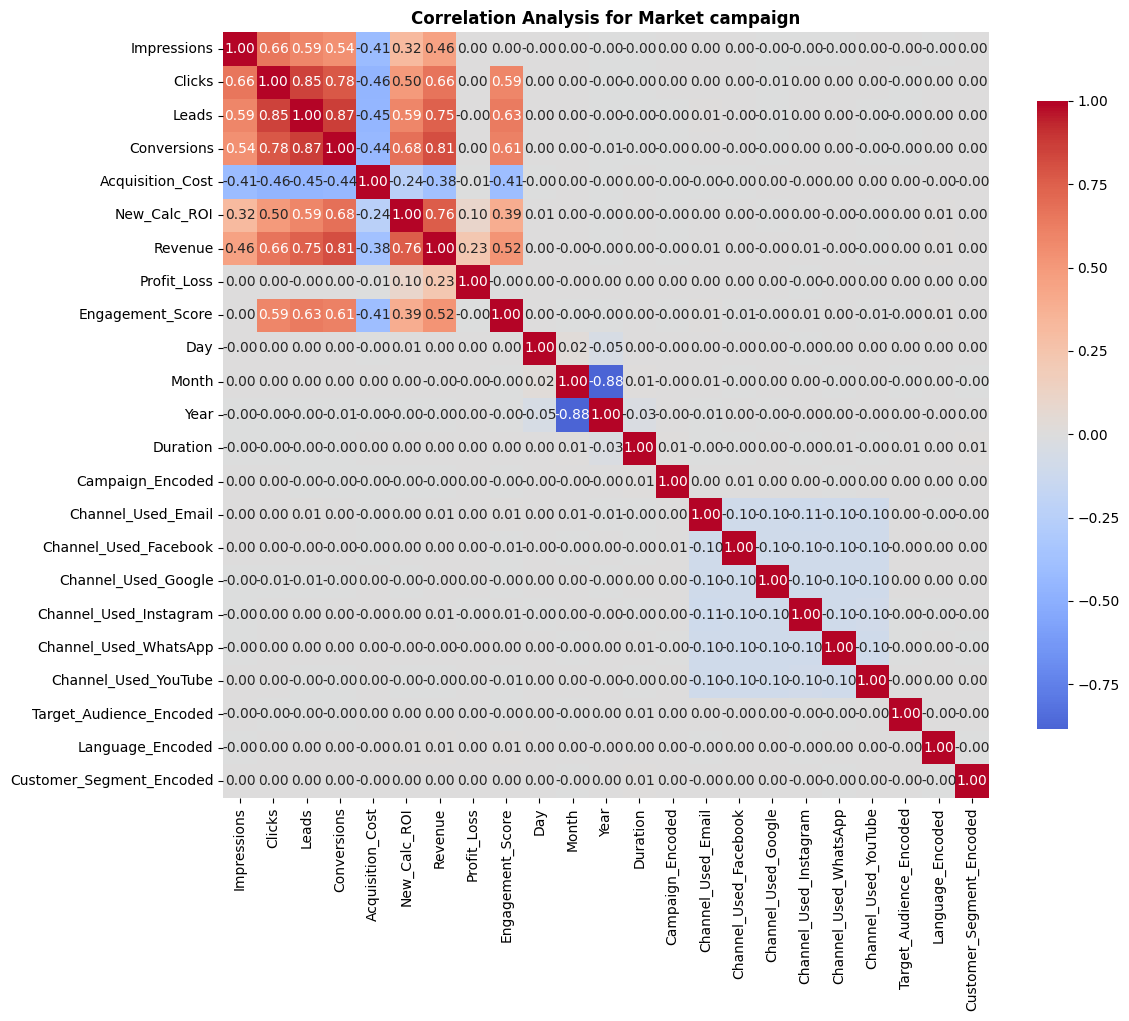

Correlation with Market Campaign: 
Profit_Loss                 1.000000
Revenue                     0.227984
New_Calc_ROI                0.097356
Language_Encoded            0.004962
Duration                    0.004762
Campaign_Encoded            0.004029
Channel_Used_Email          0.003686
Channel_Used_Google         0.003484
Target_Audience_Encoded     0.003369
Day                         0.002561
Year                        0.002271
Channel_Used_Facebook       0.002219
Customer_Segment_Encoded    0.002202
Impressions                 0.002028
Conversions                 0.001457
Channel_Used_YouTube        0.000386
Clicks                      0.000314
Leads                      -0.000164
Month                      -0.000219
Channel_Used_WhatsApp      -0.000868
Engagement_Score           -0.001404
Channel_Used_Instagram     -0.003591
Acquisition_Cost           -0.005531
Name: Profit_Loss, dtype: float64


In [29]:
# Correlation Analysis:
# Correlation tells us how strongly two variables are related
# Values range from -1 to +1:
# - +1: Perfect positive correlation (when one goes up, the other goes up)
# - 0: No correlation
# - -1: Perfect negative correlation (when one goes up, the other goes down)

classify_correlation_columns = ['Impressions','Clicks','Leads','Conversions','Acquisition_Cost','New_Calc_ROI','Revenue',
                        'Profit_Loss','Engagement_Score','Day','Month','Year','Duration','Campaign_Encoded',
                        'Channel_Used_Email','Channel_Used_Facebook','Channel_Used_Google','Channel_Used_Instagram',
                        'Channel_Used_WhatsApp','Channel_Used_YouTube','Target_Audience_Encoded','Language_Encoded',
                        'Customer_Segment_Encoded']

classify_correlation_matrix = nykaa_purplle_tira_classify_df[classify_correlation_columns].corr()

print("\nCorrelation Analysis:")
print(classify_correlation_matrix)

# Heatmap: using Matplot
plt.figure(figsize= (12,12))
sns.heatmap(classify_correlation_matrix, square= True, annot= True, 
                                center=0, cmap = 'coolwarm', fmt= '.2f', cbar_kws={"shrink": .6})
plt.title('Correlation Analysis for Market campaign' , fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.show()

# Heatmap: using Plotly:
classify_correlation_heatmap_fig = px.imshow(classify_correlation_matrix, 
                                     title='Correlation Analysis for Market campaign for Classificaton Model',
                                     color_continuous_scale="RDBu_r",
                                     color_continuous_midpoint=0,
                                     labels = dict(color="Correlation",fontsize = 10, fontweight = 'bold'),
                                     text_auto='.2f',
                                     aspect="equal"                                    
                                           )
classify_correlation_heatmap_fig.update_layout(title_x = 0.50,
                                               width=1000,
                                               height=1000,
                                               xaxis=dict(tickangle=-90),
                                               coloraxis_colorbar=dict(
                                                            len=0.9,                      
                                                            yanchor="middle",             
                                                            y=0.5     )
                                                )
classify_correlation_heatmap_fig.show()


print("Correlation with Market Campaign: ")
print(classify_correlation_matrix['Profit_Loss'].sort_values(ascending=False))


### Feature engineering:

In [30]:
# Feature engineering
# Now we'll select the specific features we want to use for our prediction model

cls_features = ['Impressions','Clicks','Leads','Acquisition_Cost','New_Calc_ROI','Engagement_Score','Conversions',
                     'Campaign_Encoded','Campaign_Type_Encoded','Target_Audience_Encoded','Language_Encoded',
                     'Customer_Segment_Encoded','Channel_Used_Email','Channel_Used_Facebook','Channel_Used_Google',
                     'Channel_Used_Instagram','Channel_Used_WhatsApp','Channel_Used_YouTube','Duration','Day','Month','Year']             

cls_target = 'Profit_Loss'

# Create our feature matrix (X) and target vector (y)
X = nykaa_purplle_tira_classify_df[cls_features]  # All the input variables, X (capital): Represents our input features (independent variables)
y = nykaa_purplle_tira_classify_df[cls_target]    # The output variable we want to predict, y (lowercase): Represents our target variable (dependent variable)
# - The goal is to find how X affects y


print(f"Features selected: {len(cls_features)}")
print(f"Target variable: {cls_target}")
print(f"Feature names: {cls_features}")

# # Check skewness
# print("\nCheck skewness: ")
# print("Matplot Graph:")
# plt.hist(y, bins=50)
# plt.title("Target Variable Distribution")
# plt.xlabel("Profit/Loss")
# plt.ylabel("Frequency")
# plt.show()

print(y.value_counts())
print(y.value_counts(normalize=True))

# print("Plotly Graph:")
# fig = px.histogram(nykaa_purplle_tira_df, x='Revenue',nbins=50)
# fig.update_layout(title="Target Variable Distribution",title_x = 0.5, xaxis_title="Revenue", yaxis_title = "Frequency")
# fig.show()

print(f"Skewness: {y.skew()}")  # If > 1, it's heavily skewed, Needed Log Transform,    skewness -> -1 to 1 = correct range
print(y.describe())             # If < 1, No need Log transform


Features selected: 22
Target variable: Profit_Loss
Feature names: ['Impressions', 'Clicks', 'Leads', 'Acquisition_Cost', 'New_Calc_ROI', 'Engagement_Score', 'Conversions', 'Campaign_Encoded', 'Campaign_Type_Encoded', 'Target_Audience_Encoded', 'Language_Encoded', 'Customer_Segment_Encoded', 'Channel_Used_Email', 'Channel_Used_Facebook', 'Channel_Used_Google', 'Channel_Used_Instagram', 'Channel_Used_WhatsApp', 'Channel_Used_YouTube', 'Duration', 'Day', 'Month', 'Year']
Profit_Loss
1    111035
0      5776
Name: count, dtype: int64
Profit_Loss
1    0.950553
0    0.049447
Name: proportion, dtype: float64
Skewness: -4.156437705890529
count    116811.000000
mean          0.950553
std           0.216801
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: Profit_Loss, dtype: float64


In [31]:
joblib.dump(cls_features, r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\models\classification_features.pkl")
print("Model trained and saved as model.pkl")

Model trained and saved as model.pkl


### Splitting the data for Training and Testing:

In [32]:
# Split the data into training and testing sets
# This is one of the most important steps in machine learning!

# - Training set: Used to teach the model the patterns in the data
# - Testing set: Used to evaluate how well the model learned (unseen data)
# - This prevents the model from 'cheating' by memorizing the answers

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(X, y, test_size=0.2, random_state = 42)
# test_size=0.2 means 20% of data for testing, 80% for training
# random_state=42 ensures we get the same split every time (for reproducibility)
# X_cls_trains = X_cls_train
# y_cls_trains = y_cls_train

# ros = RandomOverSampler(random_state=42)
# X_cls_train_ros, y_cls_train_ros = ros.fit_resample(X_cls_train, y_cls_train)
# X_cls_trains = X_cls_train_ros
# y_cls_trains = y_cls_train_ros

smote = SMOTE(random_state=42)
X_cls_train_smote, y_cls_train_smote = smote.fit_resample(X_cls_train, y_cls_train)
X_cls_trains = X_cls_train_smote
y_cls_trains = y_cls_train_smote


#Verify balance after SMOTE:
print(pd.Series(y_cls_train_smote).value_counts())
print(pd.Series(y_cls_train_smote).value_counts(normalize=True))


print("Training set shape:", X_cls_trains.shape)
print("Testing set shape:", X_cls_test.shape)
print(f"\nTraining set size in X (Total records): {X_cls_trains.shape[0]}")
print(f"Testing set size in X (Total records) : {X_cls_test.shape[0]}")

print(f"\nTraining set size in y (Total records): {y_cls_trains.shape[0]}")
print(f"Testing set size in y (Total records) : {y_cls_test.shape[0]}")


# Standardize the scalar:
# Use StandardScaler function to standardize the values for training and Testing:
scaler_cls = StandardScaler()
X_cls_train_scaled = scaler_cls.fit_transform(X_cls_trains)  # Learn scaling from training data
X_cls_test_scaled = scaler_cls.transform(X_cls_test)      # Apply same scaling to test data
# Important: We only fit on training data to avoid 'data leakage' from test set!

joblib.dump(scaler_cls, r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\models\profit_loss_classification_scaler.pkl")
print("\nModel trained and saved as model.pkl")


Profit_Loss
1    88825
0    88825
Name: count, dtype: int64
Profit_Loss
1    0.5
0    0.5
Name: proportion, dtype: float64
Training set shape: (177650, 22)
Testing set shape: (23363, 22)

Training set size in X (Total records): 177650
Testing set size in X (Total records) : 23363

Training set size in y (Total records): 177650
Testing set size in y (Total records) : 23363

Model trained and saved as model.pkl


## Classification Models:
#### 1. Logistic Regression,
#### 2. Decision Tree Classifier,
#### 3. Random Forest Classifier,
#### 4. Gradient Boost Classifier,
#### 5. Ada Boost classifier

In [33]:
#===========================
# Logistic regression model:
#===========================
log_cls_model = LogisticRegression(random_state=42)       # Train the model on our training data                                                        
log_cls_model.fit(X_cls_train_scaled, y_cls_trains)       # fit() is the method that 'learns' the relationship between X and y

# Make predictions:
# Predict on training and testing data:
y_cls_train_pred_log= log_cls_model.predict(X_cls_train_scaled)           # -> new rule
y_cls_test_pred_log = log_cls_model.predict(X_cls_test_scaled)      # -> already rule taken from train data

# Get prediction probabilities:
y_cls_train_proba_log = log_cls_model.predict_proba(X_cls_train_scaled)[:, 1]
y_cls_test_proba_log = log_cls_model.predict_proba(X_cls_test_scaled)[:, 1]

# Accuracy Score:
train_accuracy_log = accuracy_score(y_cls_trains, y_cls_train_pred_log)
test_accuracy_log = accuracy_score(y_cls_test, y_cls_test_pred_log)

# Precision:
train_precision_log = precision_score(y_cls_trains, y_cls_train_pred_log)
test_precision_log = precision_score(y_cls_test, y_cls_test_pred_log)

# Recall:
train_recall_log = recall_score(y_cls_trains, y_cls_train_pred_log)
test_recall_log = recall_score(y_cls_test, y_cls_test_pred_log)

# F1 Score:
train_f1_log = f1_score(y_cls_trains, y_cls_train_pred_log)
test_f1_log = f1_score(y_cls_test, y_cls_test_pred_log)

# AUC, ROC Curve:
train_auc_log = roc_auc_score(y_cls_trains, y_cls_train_proba_log)
test_auc_log = roc_auc_score(y_cls_test, y_cls_test_proba_log)

# Create comprehensive metrics DataFrame
log_metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Training Set': [train_accuracy_log, train_precision_log, train_recall_log, train_f1_log, train_auc_log],
    'Testing Set': [test_accuracy_log, test_precision_log, test_recall_log, test_f1_log, test_auc_log]
})

# Format the metrics as percentages
log_metrics_df['Training Set'] = log_metrics_df['Training Set'].apply(lambda x: f"{x:.4f} ({x*100:.2f}%)")
log_metrics_df['Testing Set'] = log_metrics_df['Testing Set'].apply(lambda x: f"{x:.4f} ({x*100:.2f}%)")

print("\nLogistic regression CLASSIFICATION METRICS SUMMARY:")
print("="*50)
display(log_metrics_df)



#===========================
# Decision Tree Classifier model
#===========================
dtc_cls_model = DecisionTreeClassifier(min_samples_split=10,
                                        min_samples_leaf=5, 
                                        max_depth=10, 
                                        random_state=42)      # Train the model on our training data
dtc_cls_model.fit(X_cls_train_scaled, y_cls_trains)           # fit() is the method that 'learns' the relationship between X and y

# Make predictions:
# Predict on training and testing data:
y_cls_train_pred_dtc= dtc_cls_model.predict(X_cls_train_scaled)
y_cls_test_pred_dtc = dtc_cls_model.predict(X_cls_test_scaled)

# Get prediction probabilities:
y_cls_train_proba_dtc = dtc_cls_model.predict_proba(X_cls_train_scaled)[:, 1]
y_cls_test_proba_dtc = dtc_cls_model.predict_proba(X_cls_test_scaled)[:, 1]


# Accuracy Score:
train_accuracy_dtc = accuracy_score(y_cls_trains, y_cls_train_pred_dtc)
test_accuracy_dtc = accuracy_score(y_cls_test, y_cls_test_pred_dtc)

# Precision:
train_precision_dtc = precision_score(y_cls_trains, y_cls_train_pred_dtc)
test_precision_dtc = precision_score(y_cls_test, y_cls_test_pred_dtc)

# Recall:
train_recall_dtc = recall_score(y_cls_trains, y_cls_train_pred_dtc)
test_recall_dtc = recall_score(y_cls_test, y_cls_test_pred_dtc)

# F1 Score:
train_f1_dtc = f1_score(y_cls_trains, y_cls_train_pred_dtc)
test_f1_dtc = f1_score(y_cls_test, y_cls_test_pred_dtc)

# AUC, ROC Curve:
train_auc_dtc = roc_auc_score(y_cls_trains, y_cls_train_proba_dtc)
test_auc_dtc = roc_auc_score(y_cls_test, y_cls_test_proba_dtc)


# Create comprehensive metrics DataFrame
dtc_metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Training Set': [train_accuracy_dtc, train_precision_dtc, train_recall_dtc, train_f1_dtc, train_auc_dtc],
    'Testing Set': [test_accuracy_dtc, test_precision_dtc, test_recall_dtc, test_f1_dtc, test_auc_dtc]
})

# Format the metrics as percentages
dtc_metrics_df['Training Set'] = dtc_metrics_df['Training Set'].apply(lambda x: f"{x:.4f} ({x*100:.2f}%)")
dtc_metrics_df['Testing Set'] = dtc_metrics_df['Testing Set'].apply(lambda x: f"{x:.4f} ({x*100:.2f}%)")

print("Decision Tree CLASSIFICATION METRICS SUMMARY:")
print("="*50)
display(dtc_metrics_df)



#===========================
# Random Forest Classifier model
#===========================
rf_cls_model = RandomForestClassifier(max_depth=10,
                                        min_samples_split=10, 
                                        min_samples_leaf=5, 
                                        n_estimators=100, 
                                        random_state=42)   
                                                                              
rf_cls_model.fit(X_cls_train_scaled, y_cls_trains)           
 
# Make predictions:
# Predict on training and testing data:
y_cls_train_pred_rf= rf_cls_model.predict(X_cls_train_scaled)
y_cls_test_pred_rf = rf_cls_model.predict(X_cls_test_scaled)

# Get prediction probabilities:
y_cls_train_proba_rf = rf_cls_model.predict_proba(X_cls_train_scaled)[:, 1]
y_cls_test_proba_rf = rf_cls_model.predict_proba(X_cls_test_scaled)[:, 1]


# Accuracy Score:
train_accuracy_rf = accuracy_score(y_cls_trains, y_cls_train_pred_rf)
test_accuracy_rf = accuracy_score(y_cls_test, y_cls_test_pred_rf)

# Precision:
train_precision_rf = precision_score(y_cls_trains, y_cls_train_pred_rf)
test_precision_rf = precision_score(y_cls_test, y_cls_test_pred_rf)

# Recall:
train_recall_rf = recall_score(y_cls_trains, y_cls_train_pred_rf)
test_recall_rf = recall_score(y_cls_test, y_cls_test_pred_rf)

# F1 Score:
train_f1_rf = f1_score(y_cls_trains, y_cls_train_pred_rf)
test_f1_rf = f1_score(y_cls_test, y_cls_test_pred_rf)

# AUC, ROC Curve:
train_auc_rf = roc_auc_score(y_cls_trains, y_cls_train_proba_rf)
test_auc_rf = roc_auc_score(y_cls_test, y_cls_test_proba_rf)


# Create comprehensive metrics DataFrame
rf_metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Training Set': [train_accuracy_rf, train_precision_rf, train_recall_rf, train_f1_rf, train_auc_rf],
    'Testing Set': [test_accuracy_rf, test_precision_rf, test_recall_rf, test_f1_rf, test_auc_rf]
})

# Format the metrics as percentages
rf_metrics_df['Training Set'] = rf_metrics_df['Training Set'].apply(lambda x: f"{x:.4f} ({x*100:.2f}%)")
rf_metrics_df['Testing Set'] = rf_metrics_df['Testing Set'].apply(lambda x: f"{x:.4f} ({x*100:.2f}%)")

print("Random Forest CLASSIFICATION METRICS SUMMARY:")
print("="*50)
display(rf_metrics_df)



#===========================
# Gradient Boost Classifier model
#===========================

gb_cls_model = GradientBoostingClassifier()   
                                                                              
gb_cls_model.fit(X_cls_train_scaled, y_cls_trains)           
 
# Make predictions:
# Predict on training and testing data:
y_cls_train_pred_gb= rf_cls_model.predict(X_cls_train_scaled)
y_cls_test_pred_gb = rf_cls_model.predict(X_cls_test_scaled)

# Get prediction probabilities:
y_cls_train_proba_gb = rf_cls_model.predict_proba(X_cls_train_scaled)[:, 1]
y_cls_test_proba_gb= rf_cls_model.predict_proba(X_cls_test_scaled)[:, 1]

# Accuracy Score:
train_accuracy_gb = accuracy_score(y_cls_trains, y_cls_train_pred_gb)
test_accuracy_gb = accuracy_score(y_cls_test, y_cls_test_pred_gb)

# Precision:
train_precision_gb = precision_score(y_cls_trains, y_cls_train_pred_gb)
test_precision_gb = precision_score(y_cls_test, y_cls_test_pred_gb)

# Recall:
train_recall_gb = recall_score(y_cls_trains, y_cls_train_pred_gb)
test_recall_gb = recall_score(y_cls_test, y_cls_test_pred_gb)

# F1 Score:
train_f1_gb = f1_score(y_cls_trains, y_cls_train_pred_gb)
test_f1_gb = f1_score(y_cls_test, y_cls_test_pred_gb)

# AUC, ROC Curve:
train_auc_gb = roc_auc_score(y_cls_trains, y_cls_train_proba_gb)
test_auc_gb = roc_auc_score(y_cls_test, y_cls_test_proba_gb)

# Create comprehensive metrics DataFrame
rf_metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Training Set': [train_accuracy_gb, train_precision_gb, train_recall_gb, train_f1_gb, train_auc_gb],
    'Testing Set': [test_accuracy_gb, test_precision_gb, test_recall_gb, test_f1_gb, test_auc_gb]
})

# Format the metrics as percentages
rf_metrics_df['Training Set'] = rf_metrics_df['Training Set'].apply(lambda x: f"{x:.4f} ({x*100:.2f}%)")
rf_metrics_df['Testing Set'] = rf_metrics_df['Testing Set'].apply(lambda x: f"{x:.4f} ({x*100:.2f}%)")

print("Gradient Boost CLASSIFICATION METRICS SUMMARY:")
print("="*50)
display(rf_metrics_df)



#===========================
# Adaboost Classifier model
#===========================

ada_cls_model = AdaBoostClassifier()                                                                             
ada_cls_model.fit(X_cls_train_scaled, y_cls_trains)        

# Make predictions:
# Predict on training and testing data:
y_cls_train_pred_ada = ada_cls_model.predict(X_cls_train_scaled)
y_cls_test_pred_ada = ada_cls_model.predict(X_cls_test_scaled)

# Get prediction probabilities:
y_cls_train_proba_ada = ada_cls_model.predict_proba(X_cls_train_scaled)[:, 1]
y_cls_test_proba_ada = ada_cls_model.predict_proba(X_cls_test_scaled)[:, 1]


# Accuracy Score:
train_accuracy_ada = accuracy_score(y_cls_trains, y_cls_train_pred_ada)
test_accuracy_ada = accuracy_score(y_cls_test, y_cls_test_pred_ada)

# Precision:
train_precision_ada = precision_score(y_cls_trains, y_cls_train_pred_ada)
test_precision_ada = precision_score(y_cls_test, y_cls_test_pred_ada)

# Recall:
train_recall_ada = recall_score(y_cls_trains, y_cls_train_pred_ada)
test_recall_ada = recall_score(y_cls_test, y_cls_test_pred_ada)

# F1 Score:
train_f1_ada = f1_score(y_cls_trains, y_cls_train_pred_ada)
test_f1_ada = f1_score(y_cls_test, y_cls_test_pred_ada)

# AUC, ROC Curve:
train_auc_ada = roc_auc_score(y_cls_trains, y_cls_train_proba_ada)
test_auc_ada = roc_auc_score(y_cls_test, y_cls_test_proba_ada)


# Create comprehensive metrics DataFrame
ada_metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Training Set': [train_accuracy_ada, train_precision_ada, train_recall_ada, train_f1_ada, train_auc_ada],
    'Testing Set': [test_accuracy_ada, test_precision_ada, test_recall_ada, test_f1_ada, test_auc_ada]
})

# Format the metrics as percentages
ada_metrics_df['Training Set'] = ada_metrics_df['Training Set'].apply(lambda x: f"{x:.4f} ({x*100:.2f}%)")
ada_metrics_df['Testing Set'] = ada_metrics_df['Testing Set'].apply(lambda x: f"{x:.4f} ({x*100:.2f}%)")

print("Ada Boost CLASSIFICATION METRICS SUMMARY:")
print("="*50)
display(ada_metrics_df)




Logistic regression CLASSIFICATION METRICS SUMMARY:


,Metric,Training Set,Testing Set
0,Accuracy,0.9747 (97.47%),0.9615 (96.15%)
1,Precision,0.9782 (97.82%),0.9878 (98.78%)
2,Recall,0.9711 (97.11%),0.9715 (97.15%)
3,F1-Score,0.9746 (97.46%),0.9796 (97.96%)
4,AUC-ROC,0.9975 (99.75%),0.9762 (97.62%)


Decision Tree CLASSIFICATION METRICS SUMMARY:


,Metric,Training Set,Testing Set
0,Accuracy,1.0000 (100.00%),1.0000 (100.00%)
1,Precision,1.0000 (100.00%),1.0000 (100.00%)
2,Recall,1.0000 (100.00%),1.0000 (100.00%)
3,F1-Score,1.0000 (100.00%),1.0000 (100.00%)
4,AUC-ROC,1.0000 (100.00%),1.0000 (100.00%)


Random Forest CLASSIFICATION METRICS SUMMARY:


,Metric,Training Set,Testing Set
0,Accuracy,1.0000 (100.00%),1.0000 (100.00%)
1,Precision,1.0000 (100.00%),1.0000 (100.00%)
2,Recall,1.0000 (100.00%),1.0000 (100.00%)
3,F1-Score,1.0000 (100.00%),1.0000 (100.00%)
4,AUC-ROC,1.0000 (100.00%),1.0000 (100.00%)


Gradient Boost CLASSIFICATION METRICS SUMMARY:


,Metric,Training Set,Testing Set
0,Accuracy,1.0000 (100.00%),1.0000 (100.00%)
1,Precision,1.0000 (100.00%),1.0000 (100.00%)
2,Recall,1.0000 (100.00%),1.0000 (100.00%)
3,F1-Score,1.0000 (100.00%),1.0000 (100.00%)
4,AUC-ROC,1.0000 (100.00%),1.0000 (100.00%)


Ada Boost CLASSIFICATION METRICS SUMMARY:


,Metric,Training Set,Testing Set
0,Accuracy,1.0000 (100.00%),1.0000 (100.00%)
1,Precision,1.0000 (100.00%),1.0000 (100.00%)
2,Recall,1.0000 (100.00%),1.0000 (100.00%)
3,F1-Score,1.0000 (100.00%),1.0000 (100.00%)
4,AUC-ROC,1.0000 (100.00%),1.0000 (100.00%)


In [34]:
joblib.dump(log_cls_model, r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\models\profit_loss_logistic_classification_model.pkl")
print("Model trained and saved as model.pkl")

Model trained and saved as model.pkl


In [35]:
#classification model comparison:
clf_results = pd.DataFrame({
            "Model": ["Logistic Regression","Decision Tree","Random Forest", "Gradient Boosting", "AdaBoost"],
            "Accuracy": [test_accuracy_log, test_accuracy_dtc, test_accuracy_rf, test_accuracy_gb, test_accuracy_ada],
            "Precision": [test_precision_log, test_precision_dtc, test_precision_rf, test_precision_gb, test_precision_ada],
            "Recall": [test_recall_log, test_recall_dtc, test_recall_rf, test_recall_gb, test_recall_ada],
            "F1": [test_f1_log, test_f1_dtc, test_f1_rf, test_f1_gb, test_f1_ada]
        })

clf_long = clf_results.melt( id_vars="Model",
                            var_name="Metric",
                            value_name="Score"
                            )

clf_model_comparison_fig = px.bar(clf_long,
            x="Model",
            y="Score",
            color="Metric",
            barmode="group",
            text_auto=".3f",
            title="Classification Model Comparison"
        )
clf_model_comparison_fig.update_layout(height=500, title_x = 0.3)
clf_model_comparison_fig.show()

joblib.dump(clf_model_comparison_fig, r"C:\Users\jagad\Documents\my_classes\Tasks\mini_project_3-marketing_campaign_performance_prediction\models\cls_model_comparison_chart.pkl" )
print("Classification model saved successfully!")



Classification model saved successfully!


#### Confusion Matrix:

In [36]:
# Confusion matrix:
train_cm = confusion_matrix(y_cls_trains, y_cls_train_pred_log)
test_cm = confusion_matrix(y_cls_test, y_cls_test_pred_log)

print("Training Confusion Matrix:")
print(train_cm)

print("\nTesting Confusion Matrix:")
print(test_cm)

# Confusion matrix components
tn, fp, fn, tp = confusion_matrix(y_cls_test, y_cls_test_pred_log).ravel()

# Calculate derived metrics
specificity = tn / (tn + fp)  # True Negative Rate
sensitivity = tp / (tp + fn)  # True Positive Rate (same as recall)
false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)
positive_predictive_value = tp / (tp + fp)  # Same as precision
negative_predictive_value = tn / (tn + fn)

print(f"\n CONFUSION MATRIX COMPONENTS:")
print(f"  • True Positives (TP): {tp}")
print(f"  • True Negatives (TN): {tn}")
print(f"  • False Positives (FP): {fp}")
print(f"  • False Negatives (FN): {fn}")

print(f"\n DERIVED METRICS:")
print(f"  • Sensitivity (Recall): {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"  • Specificity: {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  • False Positive Rate: {false_positive_rate:.4f} ({false_positive_rate*100:.2f}%)")
print(f"  • False Negative Rate: {false_negative_rate:.4f} ({false_negative_rate*100:.2f}%)")
print(f"  • Positive Predictive Value: {positive_predictive_value:.4f} ({positive_predictive_value*100:.2f}%)")
print(f"  • Negative Predictive Value: {negative_predictive_value:.4f} ({negative_predictive_value*100:.2f}%)")


# Confusion_matrix using Plotly:
confusion_matrix_heatmap_train_fig = px.imshow( 
                                          train_cm,
                                          text_auto=True,                                                       
                                          x=["Pred 0", "Pred 1"],
                                          y=["Actual 0", "Actual 1"],
                                          color_continuous_scale="tealgrn",
                                          aspect="auto"
                                          )

confusion_matrix_heatmap_train_fig.update_layout(width=800, height=500, 
                                            xaxis_title = "Predicted Label",
                                            yaxis_title = "Actual Label",             
                                            title= "Training Confusion Matrix",
                                            title_x = 0.5,
                                            coloraxis_colorbar_tickformat="d"                                            
                                            )

confusion_matrix_heatmap_train_fig.update_traces( texttemplate="%{z:d}" )
confusion_matrix_heatmap_train_fig.show()





confusion_matrix_heatmap_test_fig = px.imshow( 
                                          test_cm,
                                          text_auto=True,                                                       
                                          x=["Pred 0", "Pred 1"],
                                          y=["Actual 0", "Actual 1"],
                                          color_continuous_scale="tealgrn",
                                          aspect="auto"
                                          )

confusion_matrix_heatmap_test_fig.update_layout(width=800, height=500, 
                                            xaxis_title = "Predicted Label",
                                            yaxis_title = "Actual Label",             
                                            title= "Testing Confusion Matrix",
                                            title_x = 0.5,
                                            coloraxis_colorbar_tickformat="d"                                           
                                            )

confusion_matrix_heatmap_test_fig.update_traces( texttemplate="%{z:d}" )
confusion_matrix_heatmap_test_fig.show()

Training Confusion Matrix:
[[86901  1924]
 [ 2568 86257]]

Testing Confusion Matrix:
[[  887   266]
 [  633 21577]]

 CONFUSION MATRIX COMPONENTS:
  • True Positives (TP): 21577
  • True Negatives (TN): 887
  • False Positives (FP): 266
  • False Negatives (FN): 633

 DERIVED METRICS:
  • Sensitivity (Recall): 0.9715 (97.15%)
  • Specificity: 0.7693 (76.93%)
  • False Positive Rate: 0.2307 (23.07%)
  • False Negative Rate: 0.0285 (2.85%)
  • Positive Predictive Value: 0.9878 (98.78%)
  • Negative Predictive Value: 0.5836 (58.36%)
